In [13]:
# import mitsuba
import mitsuba as mi, math

import numpy as np
import matplotlib.pyplot as plt

# colocar el valor de spectral
mi.set_variant('cuda_ad_spectral')

from mitsuba import ScalarTransform4f as T

In [14]:
def gausian(lambdas: np.ndarray, mu: float, sigma: float) -> np.ndarray:
    """
    Calculate the Gaussian function value at x with mean mu and standard deviation sigma.
    Args:
        lambdas (np.ndarray): The input values (wavelengths).
        mu (float): The mean of the Gaussian.
        sigma (float): The standard deviation of the Gaussian.
    """
    return np.exp(-0.5 * ((lambdas - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

In [15]:
def camera_response_gaussian(wavelength: int, sigma:float, k: float = 3, n_wavelents: int = 5 ):
    """
    Camera response function

    Args:
        wavelength (int): Wavelength in nm.
        sigma (float): Standard deviation of the Gaussian.
        k (float, optional): Number of standard deviations. Default is 3.
        n_wavelents (int, optional): Number of wavelengths. Default is 5.
    """

    # define the wavelength range (n values)
    wavelengths = np.linspace(wavelength - k * sigma, wavelength + k * sigma, n_wavelents)

    # define the Gaussian function
    gaussian_values = gausian(wavelengths, wavelength, sigma)

    # normalize the Gaussian function (0,1)
    gaussian_values = (gaussian_values - np.min(gaussian_values)) / (np.max(gaussian_values) - np.min(gaussian_values))

    return wavelengths, gaussian_values
    

In [16]:
def load_sensor_gaussian(r: float, phi: float, theta: float, wave_lengths: np.ndarray, sigma: float, k: float = 3, n_wavelents: int = 5):
    """
    Load a sensor with Gaussian response.

    Args:
        r (float): Radius of the sensor.
        phi (float): Azimuthal angle in degrees.
        theta (float): Polar angle in degrees.
        wave_lengths (np.ndarray): Wavelengths for the Gaussian response.
        sigma (float): Standard deviation of the Gaussian.
        k (float, optional): Number of standard deviations. Default is 3.
        n_wavelents (int, optional): Number of wavelengths. Default is 5.
    """
    z = r*np.sin(math.radians(theta))
    y = r*np.cos(math.radians(theta))*np.sin(math.radians(phi))
    x = r*np.cos(math.radians(theta))*np.cos(math.radians(phi))
    
    origin = np.array([x, y, z])
    film_dic = {
        'type': 'specfilm',
        'width': 256,
        'height': 256,
        'rfilter': {
            'type': 'tent',
        }
    }

    # for wavelength in wave_lengths:
    #     # Calculate the Gaussian response for the given wavelength
    #     wavelengths, gaussian_values = camera_response_gaussian(wavelength, sigma, k, n_wavelents)

    #     # Convert numpy arrays to comma-separated strings
    #     wavelengths_str = ', '.join(str(int(w)) for w in wavelengths)
    #     gaussian_values_str = ', '.join(f'{v:.6f}' for v in gaussian_values)
        
    #     # Create a sensor with Gaussian response
    #     film_dic[f'band_{wavelength}'] = {
    #         'type': 'irregular',
    #         'wavelengths': wavelengths_str,
    #         'values': gaussian_values_str,
    #     }

    # create sensor uniform
    distancia =  wave_lengths[1] - wave_lengths[0]
    separar = distancia // 2

    for wave_length in wave_lengths:
        
        w_min = int(wave_length - separar)
        w_max = int(wave_length + separar-1)

        values = '1.0, 1.0'

        if w_min > 12000:
            values = '0.01, 0.01'

        film_dic[f'band_{wave_length}'] = {
            'type': 'regular',
            'wavelength_min': w_min,
            'wavelength_max': w_max,
            'values' : values,
        }



    
    return mi.load_dict({
        'type': 'perspective',
        'fov': 40,
        'to_world': T().look_at(
            origin=origin,
            target=[0, 0, 0],
            up=[0, 0, 1]
        ),
        'sampler': {
            'type': 'independent',
            'sample_count': 1
        },
        'film': film_dic,
        },
    )

In [17]:
wave_lengths = np.linspace(8000, 14000, 49).astype(int)

sigma = 10
r = 35
phi = 0
theta = 0
k=3
n=15

sensor = load_sensor_gaussian(r, phi, theta, wave_lengths, sigma, k, n)

In [18]:
dragon = {
    'type': 'obj',
    'filename': 'scenes/objects/dragon.obj',
    'to_world': T().translate([0, 0, 0]),
    'bsdf': {
        'type': 'diffuse',
        'reflectance': {
            'type': 'rgb',
            'value': [0.1, 0.2, 0.3]
        }
    },
    # 'emitter': {
    #     'type': 'area',
    #     'radiance': {
    #         'type': 'regular',
    #         'wavelength_min': 8000,
    #         'wavelength_max': 14000,
    #         'values': '0.1, 0.9'
    #     }
    # }
    'emitter': {
        'type': 'area',
        'radiance': {
            'type': 'blackbody',
            'wavelength_min': 8000,
            'wavelength_max': 14000,
            'temperature': 5000
        },
    }
}

In [19]:
scene = mi.load_dict({
    'type': 'scene',
    'integrator': {
        'type': 'path',
    },
    'emitter': {
        'type' : 'constant'
    },
    'dragon': dragon,
})

In [20]:
imagen = mi.render(scene, sensor=sensor, spp=1024*16)

In [21]:
print(imagen.shape)
print(np.min(imagen))
print(np.max(imagen))

(256, 256, 49)
0.0
1027.4174


0.0
544.2495


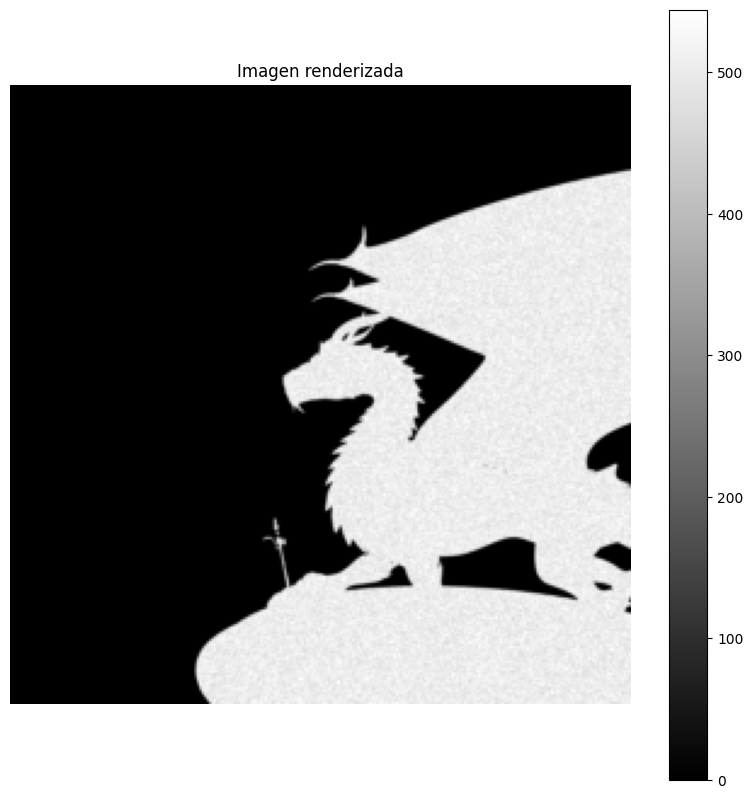

In [22]:
banda = 0

print(np.min(imagen[:, :, banda]))
print(np.max(imagen[:, :, banda]))

plt.figure(figsize=(10, 10))
plt.imshow(imagen[:, :, banda], cmap='gray')
plt.colorbar()
plt.axis('off')
plt.title('Imagen renderizada')
plt.show()

In [23]:
scenea = mi.traverse(scene)
print(scenea)

SceneParameters[
  ------------------------------------------------------------------------------------------
  Name                                   Flags    Type           Parent
  ------------------------------------------------------------------------------------------
  dragon.bsdf.reflectance.value          ∂        Color3f        SRGBReflectanceSpectrum
  dragon.emitter.sampling_weight                  float          AreaLight
  dragon.emitter.radiance.temperature             float          BlackBodySpectrum
  dragon.silhouette_sampling_weight               float          OBJMesh
  dragon.faces                                    UInt           OBJMesh
  dragon.vertex_positions                ∂, D     Float          OBJMesh
  dragon.vertex_normals                  ∂, D     Float          OBJMesh
  dragon.vertex_texcoords                ∂        Float          OBJMesh
  emitter.sampling_weight                         float          ConstantBackgroundEmitter
  emitter.radiance.ran

In [24]:
print(scenea['emitter.radiance.values'])

[0.471106, 0.498636, 0.526166, .. 89 skipped .., 0.580223, 0.594728, 0.609233]
